In [1]:
import os
import sys
import glob
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.append(project_root)

# Helper para limpiar las rutas del YAML
def clean_path(yaml_path, root):
    limpio = yaml_path.replace('../../', '').replace('../', '')
    return os.path.normpath(os.path.join(root, limpio))

# 1. Cargar Configuración
yaml_path = '../../configs/experiments/feat_task_k3_diag_pca90_bandsonly.yaml'
with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']
k = cfg['pipeline']['hmm']['k_states']

# 2. Rutas dinámicas (Extraídas del YAML para no fallar nunca)
out_dir_base = clean_path(cfg['paths']['output_dir'], project_root)
exp_dir = os.path.join(out_dir_base, exp_name)
features_dir = clean_path(cfg['paths']['features_dir'], project_root)

print(f"=== Analizando Experimento: {exp_name} ===")

# 3. Cargar Caminos de Viterbi (Con el sufijo correcto _k3)
viterbi_path = os.path.join(exp_dir, f'viterbi_paths_k{k}.npy')
viterbi_paths = np.load(viterbi_path)

# 4. Cargar el Vector Original (El de 57 columnas de bandas)
print(f"Cargando features desde: {features_dir}")
feature_files = sorted(glob.glob(os.path.join(features_dir, '*_features.npy')))

if len(feature_files) == 0:
    print("❌ ERROR: No se encontraron archivos de features en esa ruta.")
else:
    X_original = np.vstack([np.load(f) for f in feature_files])
    
    print(f"✅ Dimensiones de Viterbi: {viterbi_paths.shape}")
    print(f"✅ Dimensiones Originales: {X_original.shape}")
    
    # Prueba de sanidad: Si las filas no son exactamente iguales, algo salió muy mal
    assert viterbi_paths.shape[0] == X_original.shape[0], "¡Mismach fatal entre Viterbi y las Features!"

=== Analizando Experimento: feat_task_k3_diag_pca90_bandsonly ===
Cargando features desde: c:\Proyectos\eeg_hmm_project\data\interim\features\task_bandsonly
✅ Dimensiones de Viterbi: (143899,)
✅ Dimensiones Originales: (143899, 57)


In [4]:


scaler = StandardScaler()
X_zscored = scaler.fit_transform(X_original)

# Calcular el perfil promedio de cada estado
n_states = 3
state_profiles = []

for s in range(n_states):
    # Aislar solo las ventanas donde el cerebro estaba en el estado 's'
    idx_state = (viterbi_paths == s)
    state_mean = np.mean(X_zscored[idx_state], axis=0)
    state_profiles.append(state_mean)

state_profiles = np.array(state_profiles) # Shape: (3, 114)
print("¡Perfiles calculados exitosamente!")

¡Perfiles calculados exitosamente!


DEBUG FEATURE SPACE
Shape state_profiles: (3, 57)
Features esperadas: 57

Rango original:
Min: -2.4089
Max: 0.3353
Mean: -0.3532
STD: 0.6886

Rango normalizado:
Min: -2.8205
Max: 2.0548

Escala visual global: ±2.820


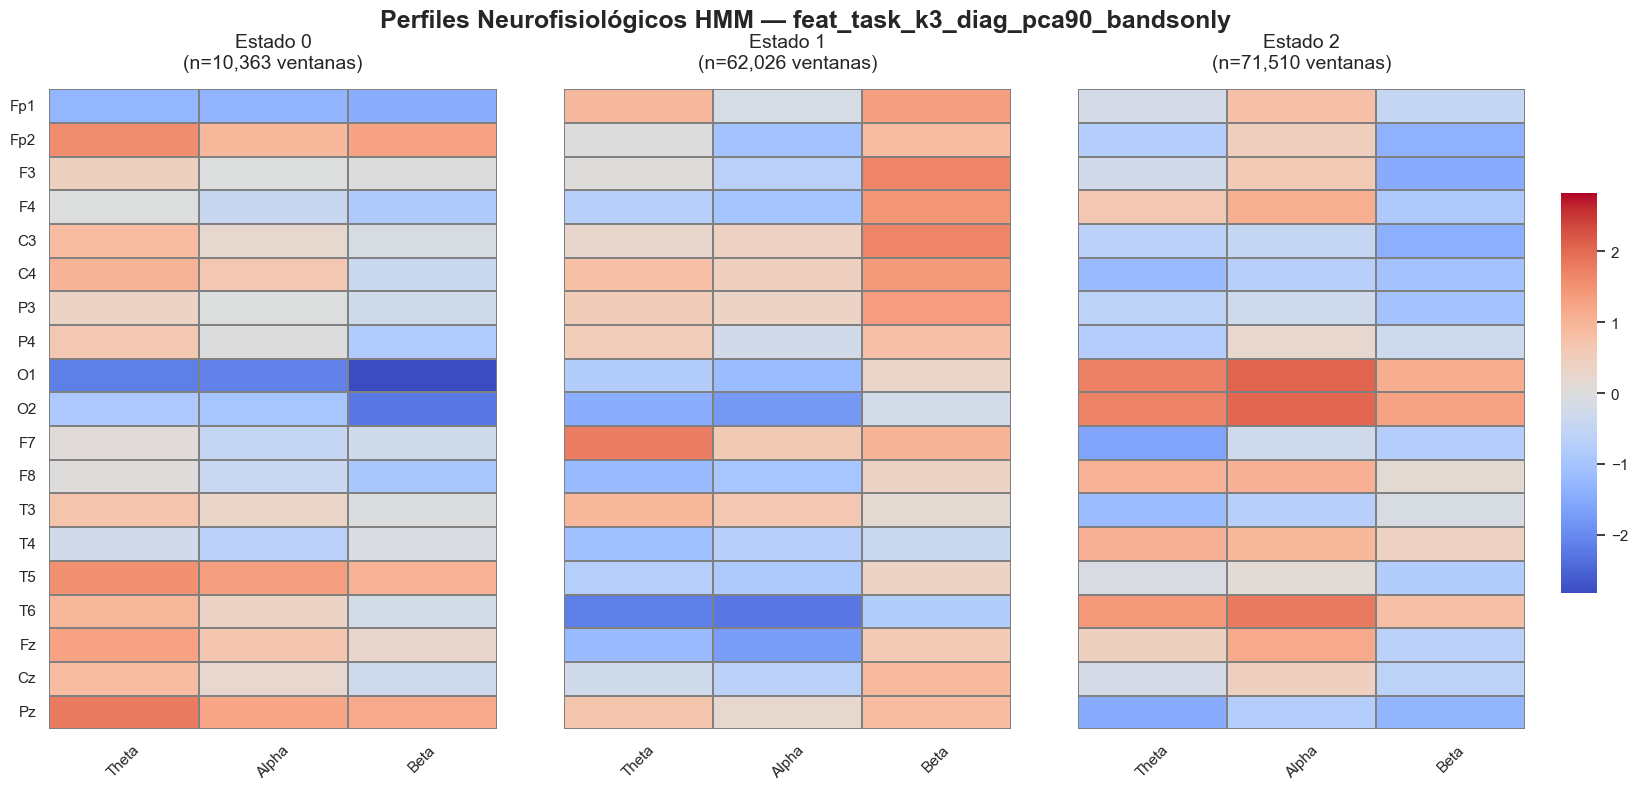

In [10]:
# ============================================================
# VISUALIZACIÓN ROBUSTA DE PERFILES HMM (BANDS ONLY)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------

ch_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

metrics = ['Theta', 'Alpha', 'Beta']

n_channels = len(ch_names)
n_metrics = len(metrics)

expected_features = n_channels * n_metrics

# ------------------------------------------------------------
# CHECKS DE INTEGRIDAD
# ------------------------------------------------------------

print("=" * 60)
print("DEBUG FEATURE SPACE")
print("=" * 60)

print(f"Shape state_profiles: {state_profiles.shape}")
print(f"Features esperadas: {expected_features}")

if state_profiles.shape[1] != expected_features:
    raise ValueError(
        f"""
ERROR:
El número de features NO coincide.

Esperadas:
{expected_features}

Encontradas:
{state_profiles.shape[1]}

Tu vector probablemente NO está organizado como:
Theta(19) + Alpha(19) + Beta(19)
"""
    )

print("\nRango original:")
print(f"Min: {state_profiles.min():.4f}")
print(f"Max: {state_profiles.max():.4f}")
print(f"Mean: {state_profiles.mean():.4f}")
print(f"STD: {state_profiles.std():.4f}")

# ------------------------------------------------------------
# NORMALIZACIÓN PARA VISUALIZACIÓN
# (MUY IMPORTANTE EN ABLATION STUDIES)
# ------------------------------------------------------------

state_profiles_norm = StandardScaler().fit_transform(
    state_profiles.T
).T

print("\nRango normalizado:")
print(f"Min: {state_profiles_norm.min():.4f}")
print(f"Max: {state_profiles_norm.max():.4f}")

# ------------------------------------------------------------
# REESTRUCTURACIÓN SEGURA
# (Estados, Canales, Métricas)
# ------------------------------------------------------------

state_profiles_3d = np.zeros(
    (n_states, n_channels, n_metrics)
)

for m_idx, metric in enumerate(metrics):

    start_col = m_idx * n_channels
    end_col = (m_idx + 1) * n_channels

    state_profiles_3d[:, :, m_idx] = (
        state_profiles_norm[:, start_col:end_col]
    )

# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

sns.set_theme(style="white")

fig, axes = plt.subplots(
    1,
    n_states,
    figsize=(6 * n_states, 8),
    sharey=True
)

# Fix cuando n_states == 1
if n_states == 1:
    axes = [axes]

# Colorbar compartido
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])

# Escala global robusta
global_absmax = np.max(np.abs(state_profiles_3d))

print(f"\nEscala visual global: ±{global_absmax:.3f}")

for s in range(n_states):

    ax = axes[s]

    sns.heatmap(
        state_profiles_3d[s],
        cmap='coolwarm',
        center=0,
        vmin=-global_absmax,
        vmax=global_absmax,
        xticklabels=metrics,
        yticklabels=ch_names,
        linewidths=0.3,
        linecolor='gray',
        annot=False,
        ax=ax,
        cbar=(s == 0),
        cbar_ax=None if s > 0 else cbar_ax
    )

    n_windows = np.sum(viterbi_paths == s)

    ax.set_title(
        f"Estado {s}\n(n={n_windows:,} ventanas)",
        fontsize=14,
        pad=15
    )

    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# ------------------------------------------------------------
# TÍTULOS
# ------------------------------------------------------------

plt.suptitle(
    f"Perfiles Neurofisiológicos HMM — {exp_name}",
    fontsize=18,
    y=0.98,
    fontweight='bold'
)

plt.subplots_adjust(
    left=0.08,
    right=0.9,
    top=0.88,
    bottom=0.08,
    wspace=0.15
)

plt.show()

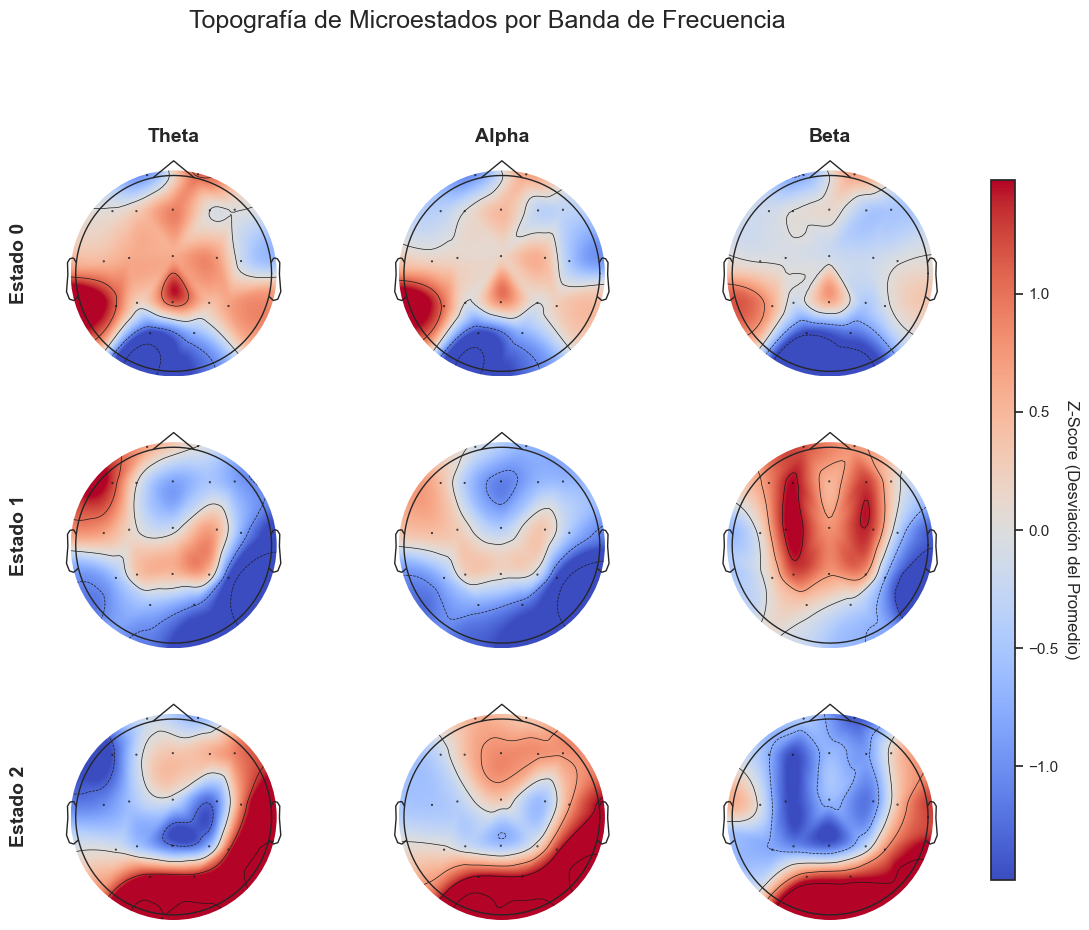

In [11]:
import mne
import matplotlib.pyplot as plt

# 1. Crear la "plantilla" de la cabeza (Montage)
# Usamos tus mismos 19 canales en el orden exacto de tu Mega-Vector
ch_names = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']

# Creamos un objeto Info de MNE y le asignamos el casco estándar 10-20
info = mne.create_info(ch_names=ch_names, sfreq=250., ch_types='eeg') # sfreq es irrelevante para el mapa espacial
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

# 2. Seleccionar qué métricas queremos ver en las cabezas
# Índices de tus métricas: 0=Theta, 1=Alpha, 2=Beta
metric_indices = {'Theta': 0, 'Alpha': 1, 'Beta': 2}
n_metrics = len(metric_indices)

# 3. Dibujar el Grid (3 Estados x 3 Bandas)
fig, axes = plt.subplots(n_states, n_metrics, figsize=(12, 10))

for s in range(n_states):
    for m_idx, (m_name, m_col) in enumerate(metric_indices.items()):
        ax = axes[s, m_idx]
        
        # Extraer los 19 valores (uno por canal) para este estado y esta métrica
        # state_profiles_3d viene de tu celda de visualización anterior!
        data_to_plot = state_profiles_3d[s, :, m_col] 
        
        # El motor de MNE que dibuja la cabecita
        im, _ = mne.viz.plot_topomap(
            data_to_plot, 
            pos=info, 
            axes=ax, 
            cmap='coolwarm', 
            vlim=(None, None), # Límites fijos de Z-score para comparar colores
            show=False,
            contours=4, # Agrega líneas topográficas como si fuera un mapa geográfico
            sphere=(0.0, 0.0, 0.0, 0.1) # Ajuste visual de la cabeza
        )
        
        # Títulos
        if s == 0:
            ax.set_title(f"{m_name}", fontsize=14, fontweight='bold')
        if m_idx == 0:
            ax.set_ylabel(f"Estado {s}", fontsize=14, fontweight='bold', labelpad=20)

# Barra de color compartida
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Z-Score (Desviación del Promedio)', rotation=270, labelpad=15)

plt.suptitle("Topografía de Microestados por Banda de Frecuencia", fontsize=18, y=1.02)
plt.show()

In [17]:
# ============================================================
# CÁLCULO CORRECTO DE STATE PROFILES (ESCALADOS)
# ============================================================

import joblib

# Cargar scaler EXACTO del experimento actual
scaler_path = os.path.join(exp_dir, 'scaler.pkl')

print(f"Cargando scaler desde:\n{scaler_path}")

scaler = joblib.load(scaler_path)

# IMPORTANTÍSIMO:
# usar el mismo scaling del entrenamiento HMM
X_scaled = scaler.transform(X_original)

# Construcción de perfiles promedio por estado
state_profiles = np.zeros((n_states, X_scaled.shape[1]))

for s in range(n_states):

    idx = (viterbi_paths == s)

    state_profiles[s] = np.mean(
        X_scaled[idx],
        axis=0
    )

print("\n" + "=" * 60)
print("DEBUG STATE PROFILES")
print("=" * 60)

print(f"Shape state_profiles: {state_profiles.shape}")

print("\nRango ORIGINAL:")
print(f"Min:  {X_original.min():.4f}")
print(f"Max:  {X_original.max():.4f}")
print(f"Mean: {X_original.mean():.4f}")
print(f"STD:  {X_original.std():.4f}")

print("\nRango NORMALIZADO:")
print(f"Min:  {state_profiles.min():.4f}")
print(f"Max:  {state_profiles.max():.4f}")
print(f"Mean: {state_profiles.mean():.4f}")
print(f"STD:  {state_profiles.std():.4f}")

# Escala dinámica para visualización
global_absmax = np.max(np.abs(state_profiles))

print(f"\nEscala visual global: ±{global_absmax:.3f}")

Cargando scaler desde:
c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k3_diag_pca90_bandsonly\scaler.pkl

DEBUG STATE PROFILES
Shape state_profiles: (3, 57)

Rango ORIGINAL:
Min:  -19.3743
Max:  -9.5496
Mean: -13.0790
STD:  0.7341

Rango NORMALIZADO:
Min:  -2.4089
Max:  0.3353
Mean: -0.3532
STD:  0.6886

Escala visual global: ±2.409


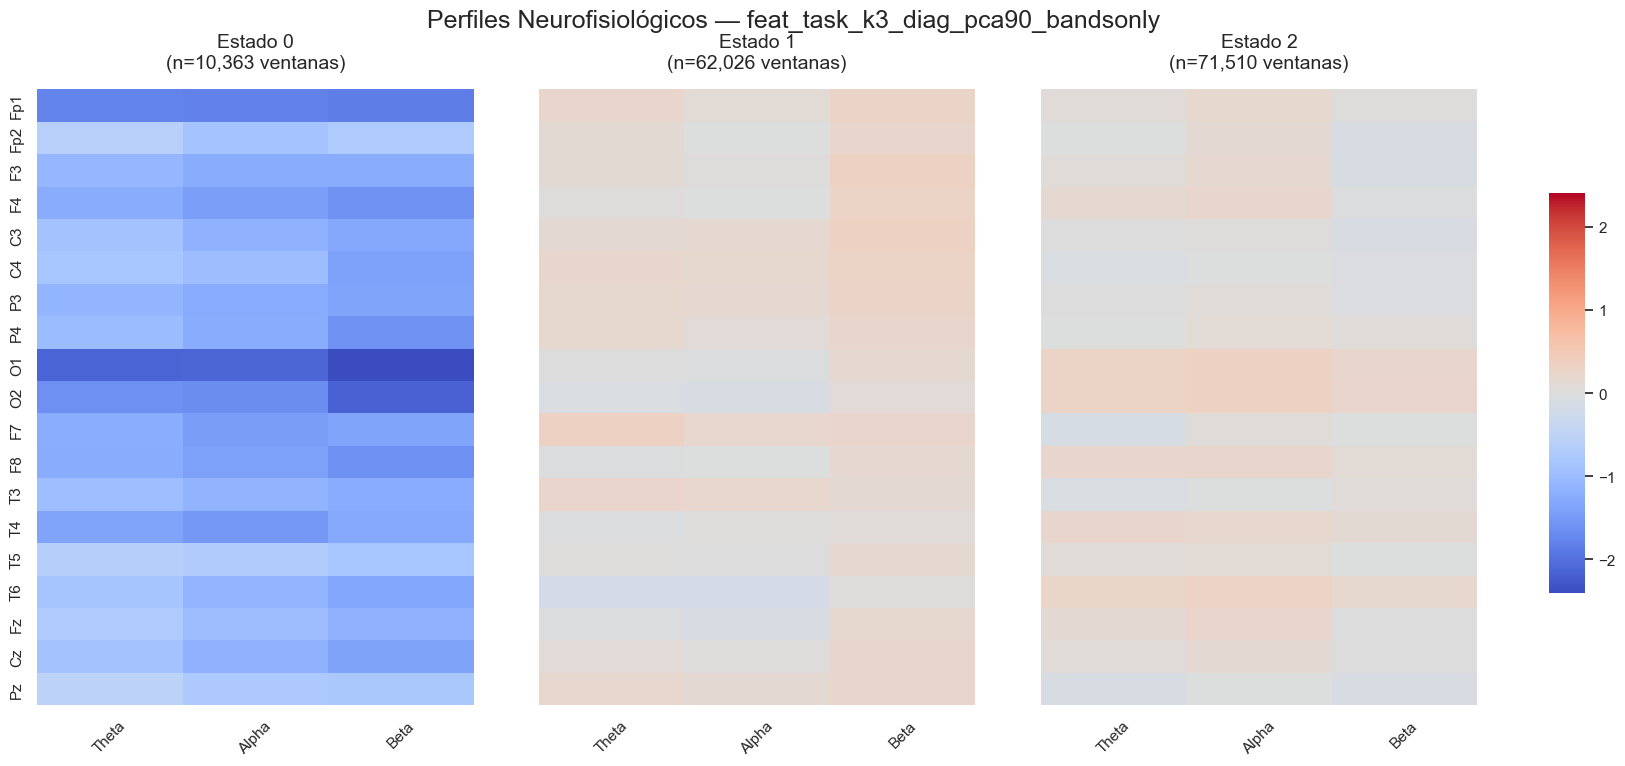

In [18]:
# ============================================================
# VISUALIZACIÓN CORRECTA DE PERFILES ESPECTRALES
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Canales EEG
ch_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

# SOLO BANDAS
metrics = ['Theta', 'Alpha', 'Beta']

# Reestructuración segura
state_profiles_3d = np.zeros(
    (n_states, len(ch_names), len(metrics))
)

for m_idx, metric in enumerate(metrics):

    start_col = m_idx * len(ch_names)
    end_col = (m_idx + 1) * len(ch_names)

    state_profiles_3d[:, :, m_idx] = state_profiles[:, start_col:end_col]

# ============================================================
# PLOTEO
# ============================================================

fig, axes = plt.subplots(
    1,
    n_states,
    figsize=(6 * n_states, 8),
    sharey=True
)

# Fix por si K=1
if n_states == 1:
    axes = [axes]

cbar_ax = fig.add_axes([.92, .25, .02, .5])

# Escala REAL dinámica
vlim = np.max(np.abs(state_profiles_3d))

for s in range(n_states):

    ax = axes[s]

    sns.heatmap(
        state_profiles_3d[s],
        cmap='coolwarm',
        center=0,
        annot=False,
        xticklabels=metrics,
        yticklabels=ch_names,
        ax=ax,
        cbar=(s == 0),
        cbar_ax=None if s > 0 else cbar_ax,
        vmin=-vlim,
        vmax=vlim
    )

    n_windows = np.sum(viterbi_paths == s)

    ax.set_title(
        f"Estado {s}\n(n={n_windows:,} ventanas)",
        fontsize=14,
        pad=15
    )

    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    f"Perfiles Neurofisiológicos — {exp_name}",
    fontsize=18,
    y=0.98
)

plt.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.88,
    wspace=0.15
)

plt.show()

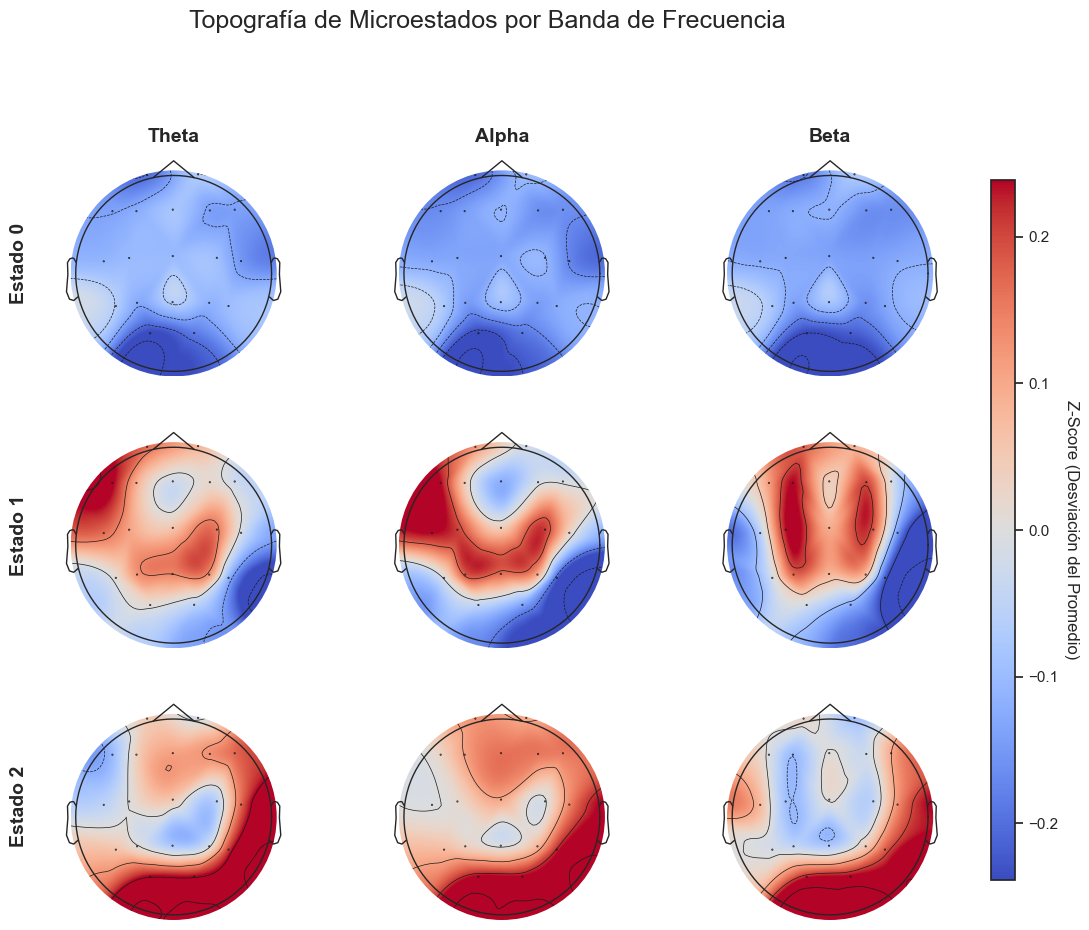

In [19]:
import mne
import matplotlib.pyplot as plt

# 1. Crear la "plantilla" de la cabeza (Montage)
# Usamos tus mismos 19 canales en el orden exacto de tu Mega-Vector
ch_names = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']

# Creamos un objeto Info de MNE y le asignamos el casco estándar 10-20
info = mne.create_info(ch_names=ch_names, sfreq=250., ch_types='eeg') # sfreq es irrelevante para el mapa espacial
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

# 2. Seleccionar qué métricas queremos ver en las cabezas
# Índices de tus métricas: 0=Theta, 1=Alpha, 2=Beta
metric_indices = {'Theta': 0, 'Alpha': 1, 'Beta': 2}
n_metrics = len(metric_indices)

# 3. Dibujar el Grid (3 Estados x 3 Bandas)
fig, axes = plt.subplots(n_states, n_metrics, figsize=(12, 10))

for s in range(n_states):
    for m_idx, (m_name, m_col) in enumerate(metric_indices.items()):
        ax = axes[s, m_idx]
        
        # Extraer los 19 valores (uno por canal) para este estado y esta métrica
        # state_profiles_3d viene de tu celda de visualización anterior!
        data_to_plot = state_profiles_3d[s, :, m_col] 
        
        # El motor de MNE que dibuja la cabecita
        im, _ = mne.viz.plot_topomap(
            data_to_plot, 
            pos=info, 
            axes=ax, 
            cmap='coolwarm', 
            vlim=(None, None), # Límites fijos de Z-score para comparar colores
            show=False,
            contours=4, # Agrega líneas topográficas como si fuera un mapa geográfico
            sphere=(0.0, 0.0, 0.0, 0.1) # Ajuste visual de la cabeza
        )
        
        # Títulos
        if s == 0:
            ax.set_title(f"{m_name}", fontsize=14, fontweight='bold')
        if m_idx == 0:
            ax.set_ylabel(f"Estado {s}", fontsize=14, fontweight='bold', labelpad=20)

# Barra de color compartida
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Z-Score (Desviación del Promedio)', rotation=270, labelpad=15)

plt.suptitle("Topografía de Microestados por Banda de Frecuencia", fontsize=18, y=1.02)
plt.show()